In [8]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import time

In [9]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

In [10]:
BATCH_SIZE = 32

def preprocess(image, label):
    image = tf.image.resize(image, (224, 224))
    return image, label

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train))
train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(10000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test))
test_ds = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [11]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

In [12]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 batch_normalization_1 (Batc  (None, 1280)             5120      
 hNormalization)                                                 
                                                                 
 dense_2 (Dense)             (None, 256)               327936    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 10)               

In [14]:
start_time = time.time()

history = model.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time: {training_time:.2f} seconds")

Epoch 1/10
1563/1563 [==============================] - 87s 52ms/step - loss: 2.3751 - accuracy: 0.1024 - val_loss: 2.2974 - val_accuracy: 0.1051
Epoch 2/10
1563/1563 [==============================] - 82s 52ms/step - loss: 2.3308 - accuracy: 0.1085 - val_loss: 2.2976 - val_accuracy: 0.1001
Epoch 3/10
1563/1563 [==============================] - 82s 52ms/step - loss: 2.3171 - accuracy: 0.1128 - val_loss: 2.2945 - val_accuracy: 0.1208
Epoch 4/10
1563/1563 [==============================] - 82s 52ms/step - loss: 2.3079 - accuracy: 0.1164 - val_loss: 2.2952 - val_accuracy: 0.1007
Epoch 5/10
1563/1563 [==============================] - 82s 52ms/step - loss: 2.3017 - accuracy: 0.1193 - val_loss: 2.2944 - val_accuracy: 0.1147
Epoch 6/10
1563/1563 [==============================] - 92s 59ms/step - loss: 2.2957 - accuracy: 0.1227 - val_loss: 2.2926 - val_accuracy: 0.1173
Epoch 7/10
1563/1563 [==============================] - 86s 55ms/step - loss: 2.2893 - accuracy: 0.1266 - val_loss: 2.2896 -

In [15]:
test_loss, test_acc = model.evaluate(test_ds, verbose=0)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 10.53%
Test Loss: 2.2877


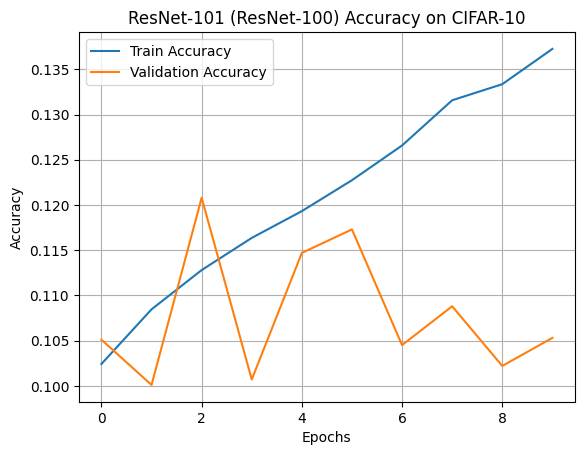

In [16]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('ResNet-101 (ResNet-100) Accuracy on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

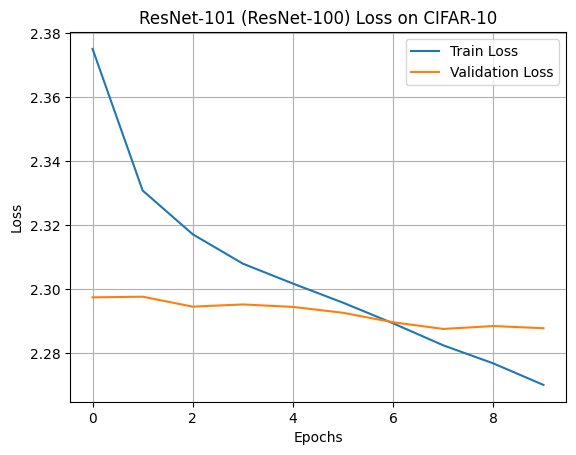

In [17]:
plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('ResNet-101 (ResNet-100) Loss on CIFAR-10')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
print(f"Total Parameters: {model.count_params():,}")

Total Parameters: 4,385,197
